In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# NOTA IMPORTANTE: AQUÍ SÓLO SE MUESTRA EL CÓDIGO NECESARIO PARA APLICAR RANDOM FOREST.

# RECUÉRDESE LA IMPORTANCIA DE LOS PASOS A SEGUIR PARA IMPLEMENTAR DE FORMA ADECUADA UN MODELO:
# (1) CARGAR BASE DE DATOS Y CONOCER FRECUENCIA DE CLASES O DISTRIBUCIÓN DE ACUERDO CON EL TIPO DE PROBLEMA.
# (2) DIVIR TRAIN, TEST Y COMPROBAR SI LA DISTRIBUCIÓN DE LA VARIABLE DEPENDIENTE ES SIMILAR EN AMBOS SETS.
# (3) AJUSTAR EL MODELO Y VALORAR LAS NECESIDADES DE INVESTIGACIÓN PARA DAR MÁS PESO A UNAS MEDIDAS DE BONDAD DE AJUSTE CON RESPECTO A OTRAS. 
# (3.1) APLICAR VALIDACIÓN CRUZADA Y, EN CASO DE NECESIDAD, UN GRIDSEARCH PARA CONOCER LAS BONDADES DE AJUSTE PARA DISTINTAS PARAMETRIZACIONES.
# (4) HACER PREDICCIONES SOBRE TRAIN Y TEST CON EL FIN DE OBSERVAR EL POSIBLE SOBREAJUSTE. VALORAR EN TEST LA CAPACIDAD PREDICTIVA DEL MODELO.
# (5) SELECCIONAR LAS ALTERNATIVAS QUE MÁS NOS INTERESEN POR SU BONDAD DE AJUSTE ESPECÍFICA.
# (6) MOSTRAR BOXPLOTS DE SU PERFORMANCE EN LAS DISTINTAS VALIDACIONES PARA VALORAR LA ROBUSTEZ Y TOMAR UNA DECISIÓN.
# (7) HACER UN INFORME DE LA PARAMETRIZACIÓN Y BONDAD DE AJUSTE DEL MODELO FINAL SELECCIONADO.

In [23]:
#file_path = "C:/Users/user/OneDrive - Universidad Complutense de Madrid (UCM)/Escritorio/A_Doctorado/23/00_DOCENCIA/Máster Tit_Propio/Árboles/arboles.csv"  # Reemplaza con la ruta correcta de tu archivo
file_path_2 = r"C:\Users\Sebitas\Downloads\Documentación machine learning - Juan Antonio Guevara-20260206/arboles.csv"
df = pd.read_csv(file_path_2)
print(df.head())
print(f"\nLa frecuencia de cada clase es: \n{df.chd.value_counts(normalize=True)}")
print(df.info())

   sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  age  chd
0  160    12.00  5.73      23.11  Present     49    25.30    97.20   52    1
1  144     0.01  4.41      28.61   Absent     55    28.87     2.06   63    1
2  118     0.08  3.48      32.28  Present     52    29.14     3.81   46    0
3  170     7.50  6.41      38.03  Present     51    31.99    24.26   58    1
4  134    13.60  3.50      27.78  Present     60    25.99    57.34   49    1

La frecuencia de cada clase es: 
chd
0    0.65368
1    0.34632
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    

In [13]:
df.describe()

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,138.326840,3.635649,4.740325,25.406732,53.103896,26.044113,17.044394,42.816017
std,20.496317,4.593024,2.070909,7.780699,9.817534,4.213680,24.481059,14.608956
min,101.000000,0.000000,0.980000,6.740000,13.000000,14.700000,0.000000,15.000000
25%,124.000000,0.052500,3.282500,19.775000,47.000000,22.985000,0.510000,31.000000
50%,134.000000,2.000000,4.340000,26.115000,53.000000,25.805000,7.510000,45.000000
75%,148.000000,5.500000,5.790000,31.227500,60.000000,28.497500,23.892500,55.000000
max,218.000000,31.200000,15.330000,42.490000,78.000000,46.580000,147.190000,64.000000


In [6]:
df.isna().sum()

sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64

In [24]:
# Categorizar la variable de respuesta
df["chd"] = df["chd"].apply(lambda x: "Yes" if x == 1 else "No")
print(df.head())

   sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  age  chd
0  160    12.00  5.73      23.11  Present     49    25.30    97.20   52  Yes
1  144     0.01  4.41      28.61   Absent     55    28.87     2.06   63  Yes
2  118     0.08  3.48      32.28  Present     52    29.14     3.81   46   No
3  170     7.50  6.41      38.03  Present     51    31.99    24.26   58  Yes
4  134    13.60  3.50      27.78  Present     60    25.99    57.34   49  Yes


In [25]:
#es importante tratar de forma adecuada las variables categóricas. Se convierten en numéricas con la regla: one hot encoding.
df[["famhist"]] = pd.get_dummies(df[["famhist"]],drop_first=True)
# Separar las variables predictoras y la variable de respuesta.
X = df.drop("chd", axis=1)
y = df["chd"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Ejemplo con solo una predictora, tobacco

In [26]:
# Separar las variables predictoras y la variable de respuesta.
X = df[["tobacco"]]
y = df["chd"]
# min_sample_split: el número mínimo de casos que contiene una hoja para que pueda ser creada.
# criterion: Criterio de división: “gini”, “entropy”, “log_loss”.
# max_depth = Profundidad máxima del árbol. En caso de no especificar, el clasificador sigue segmentando hasta
# que las hojas son puras, o se alcanza el min_sample_split. Con caracter ilustrativo, se selecciona bajo.
arbol1 = DecisionTreeClassifier(min_samples_split=30, criterion="gini", max_depth = 2)
# Crear un conjunto de entrenamiento y uno de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
print(f"La frecuencia de cada clase en train es: \n{y_train.value_counts(normalize=True)}")
print(f"La frecuencia de cada clase en test es: \n{y_test.value_counts(normalize=True)}")

SyntaxError: unterminated f-string literal (detected at line 2) (1398221982.py, line 2)

In [29]:
arbol1.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [30]:
# Conocer los niveles de la variable a predecir
print(arbol1.classes_)
# Conocer el nombre de las variables predictoras
print(arbol1.feature_names_in_)
# Obtener información detallada de cada nodo y las reglas de decisión
tree_rules = export_text(arbol1, feature_names=list(X.columns),show_weights=True)
print(tree_rules)


['No' 'Yes']
['tobacco']
|--- tobacco <= 0.48
|   |--- tobacco <= 0.41
|   |   |--- weights: [96.00, 18.00] class: No
|   |--- tobacco >  0.41
|   |   |--- weights: [4.00, 0.00] class: No
|--- tobacco >  0.48
|   |--- tobacco <= 8.04
|   |   |--- weights: [127.00, 78.00] class: No
|   |--- tobacco >  8.04
|   |   |--- weights: [16.00, 30.00] class: Yes



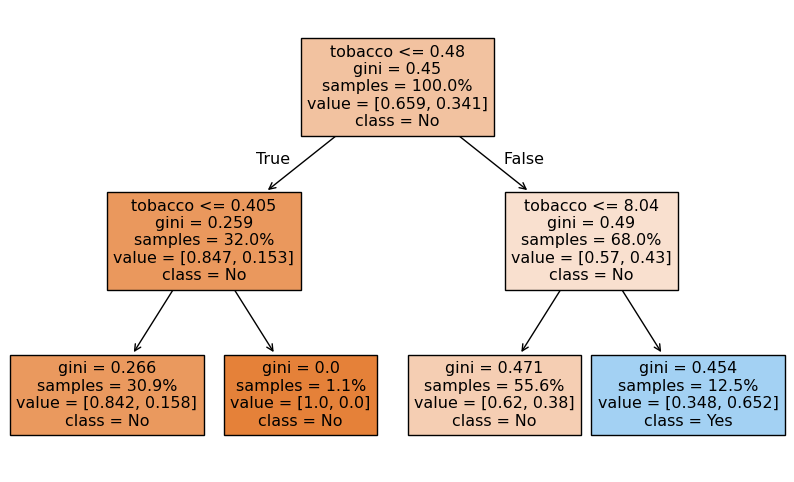

In [31]:
plt.figure(figsize=(10, 6))
plot_tree(arbol1, feature_names=X.columns.tolist(), class_names=["No", "Yes"], filled=True,
proportion = True)
plt.show()
# Colores más claros indican nodos de peor calidad. Un Azul muy saturado indica que es una regla muy buena a priori para el si. 
# Un naranja muy saturado para los NO indica que es una muy buena regla a priori.

# Se vuelve a entrenar el árbol con más variables.

In [34]:
#es importante tratar de forma adecuada las variables categóricas. Se convierten en numéricas con la regla: one hot encoding.
df[["famhist"]] = pd.get_dummies(df[["famhist"]],drop_first=True)
# Separar las variables predictoras y la variable de respuesta.
X = df.drop("chd", axis=1)
y = df["chd"]
#Se selecciona profundidad 4 sólo con caracter ilustrativo, al simplificar el árbol.
arbol2 = DecisionTreeClassifier(min_samples_split=30, criterion="gini", max_depth = 4)
# Crear un conjunto de entrenamiento y uno de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Construir el modelo de árbol de decisiones
arbol2.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

      nombre  importancia
0        sbp     0.049070
1    tobacco     0.000000
2        ldl     0.179858
3  adiposity     0.000000
4    famhist     0.056089
5      typea     0.094607
6    obesity     0.105539
7    alcohol     0.000000
8        age     0.514837


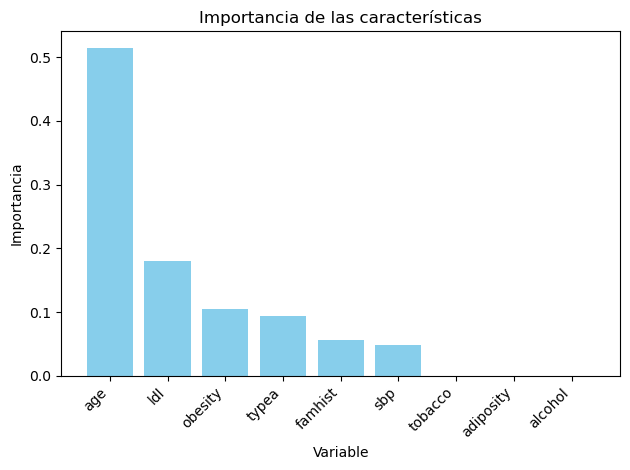

In [35]:
# Se estudia la importancia - o valor predictivo - de cada variable en el modelo.
print(pd.DataFrame({"nombre": arbol2.feature_names_in_, "importancia": arbol2.feature_importances_}))
# Ordenar el DataFrame por importancia en orden descendente
df_importancia = pd.DataFrame({"Variable": arbol2.feature_names_in_, "Importancia":
arbol2.feature_importances_}).sort_values(by="Importancia", ascending=False)
# Crear un gráfico de barras
plt.bar(df_importancia["Variable"], df_importancia["Importancia"], color="skyblue")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.title("Importancia de las características")
plt.xticks(rotation=45, ha="right") # Rotar los nombres en el eje x para mayor legibilidad
plt.tight_layout()
# Mostrar el gráfico
plt.show()


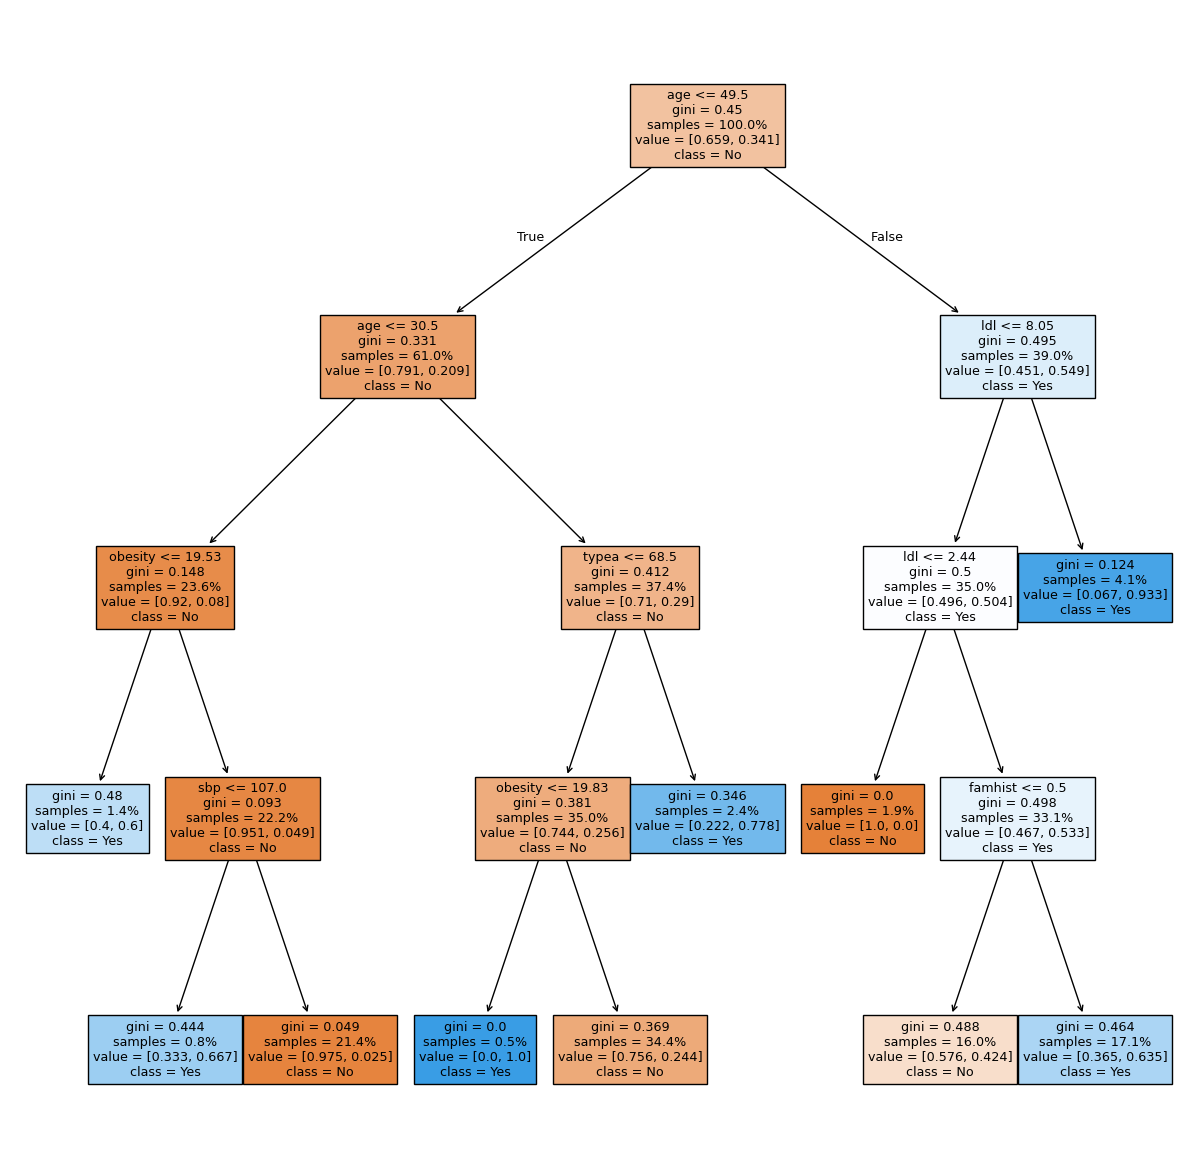

In [36]:
plt.figure(figsize=(15, 15))
plot_tree(arbol2, feature_names=X.columns.tolist(),
class_names=["No", "Yes"], filled=True,
proportion = True)
plt.show()

# Árboles de regresión:

In [38]:
file_path = r"C:\Users\Sebitas\Downloads\Documentación machine learning - Juan Antonio Guevara-20260206/compress.csv"
compress = pd.read_csv(file_path)
compress.head()
#compress.isna().sum()

,cstrength,cement,blast,ash,water,plasti,aggreg,fineagg,age
0,79.99,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,61.89,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,40.27,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,41.05,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,44.30,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [39]:
compress.isna().sum()

cstrength    0
cement       0
blast        0
ash          0
water        0
plasti       0
aggreg       0
fineagg      0
age          0
dtype: int64

In [40]:
# Separar las variables predictoras y la variable de respuesta.
X_c = compress.drop("cstrength", axis=1)
y_c = compress["cstrength"]
# criterion: Criterio de división: “squared_error”, “friedman_mse”, “absolute_error”, “poisson”}, default=”squared_error”.
# Se selecciona squared error con motivos ilustrativos. Es equivalente a la reducción de varianza.
# A priori, con motivos ilustrativos, se mantiene min_sample_split y max_depth en estos valores para facilitar la visualización del árbol.
# Recordar que estos son parámetros a modificar para encontrar el modelo óptimo.
# cpp_alpha es el parámetro de complejidad, el cual establece “penalizaciones” si se producen muchas divisiones. Cuanto más alto
# más pequeño será el árbol.
arbol3 = DecisionTreeRegressor(min_samples_split=30, criterion="squared_error", max_depth = 4, ccp_alpha = 0.01)
# Crear un conjunto de entrenamiento y uno de prueba
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)
# Construir el modelo de árbol de decisiones
arbol3.fit(X_train_c, y_train_c)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

    nombre  importancia
0   cement     0.430857
1    blast     0.034447
2      ash     0.020320
3    water     0.141266
4   plasti     0.004367
5   aggreg     0.000000
6  fineagg     0.000000
7      age     0.368743


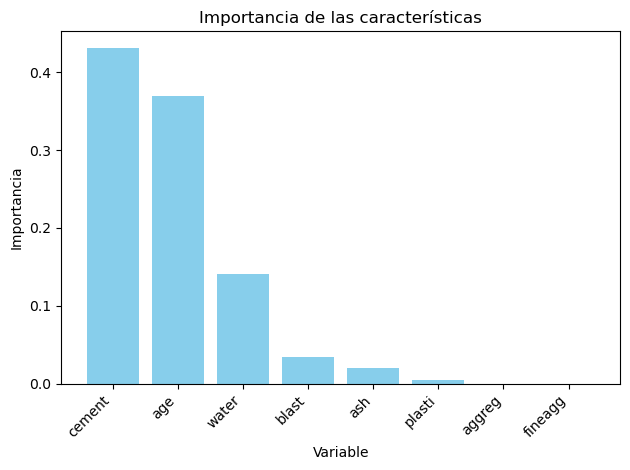

In [41]:
print(pd.DataFrame({"nombre": arbol3.feature_names_in_, "importancia": arbol3.feature_importances_}))
# Ordenar el DataFrame por importancia en orden descendente
df_importancia_c = pd.DataFrame({"Variable": arbol3.feature_names_in_, "Importancia": arbol3.feature_importances_}).sort_values(by="Importancia",
ascending=False)
# Crear un gráfico de barras
plt.bar(df_importancia_c["Variable"], df_importancia_c["Importancia"], color="skyblue")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.title("Importancia de las características")
plt.xticks(rotation=45, ha="right") # Rotar los nombres en el eje x para mayor legibilidad
plt.tight_layout()
# Mostrar el gráfico
plt.show()


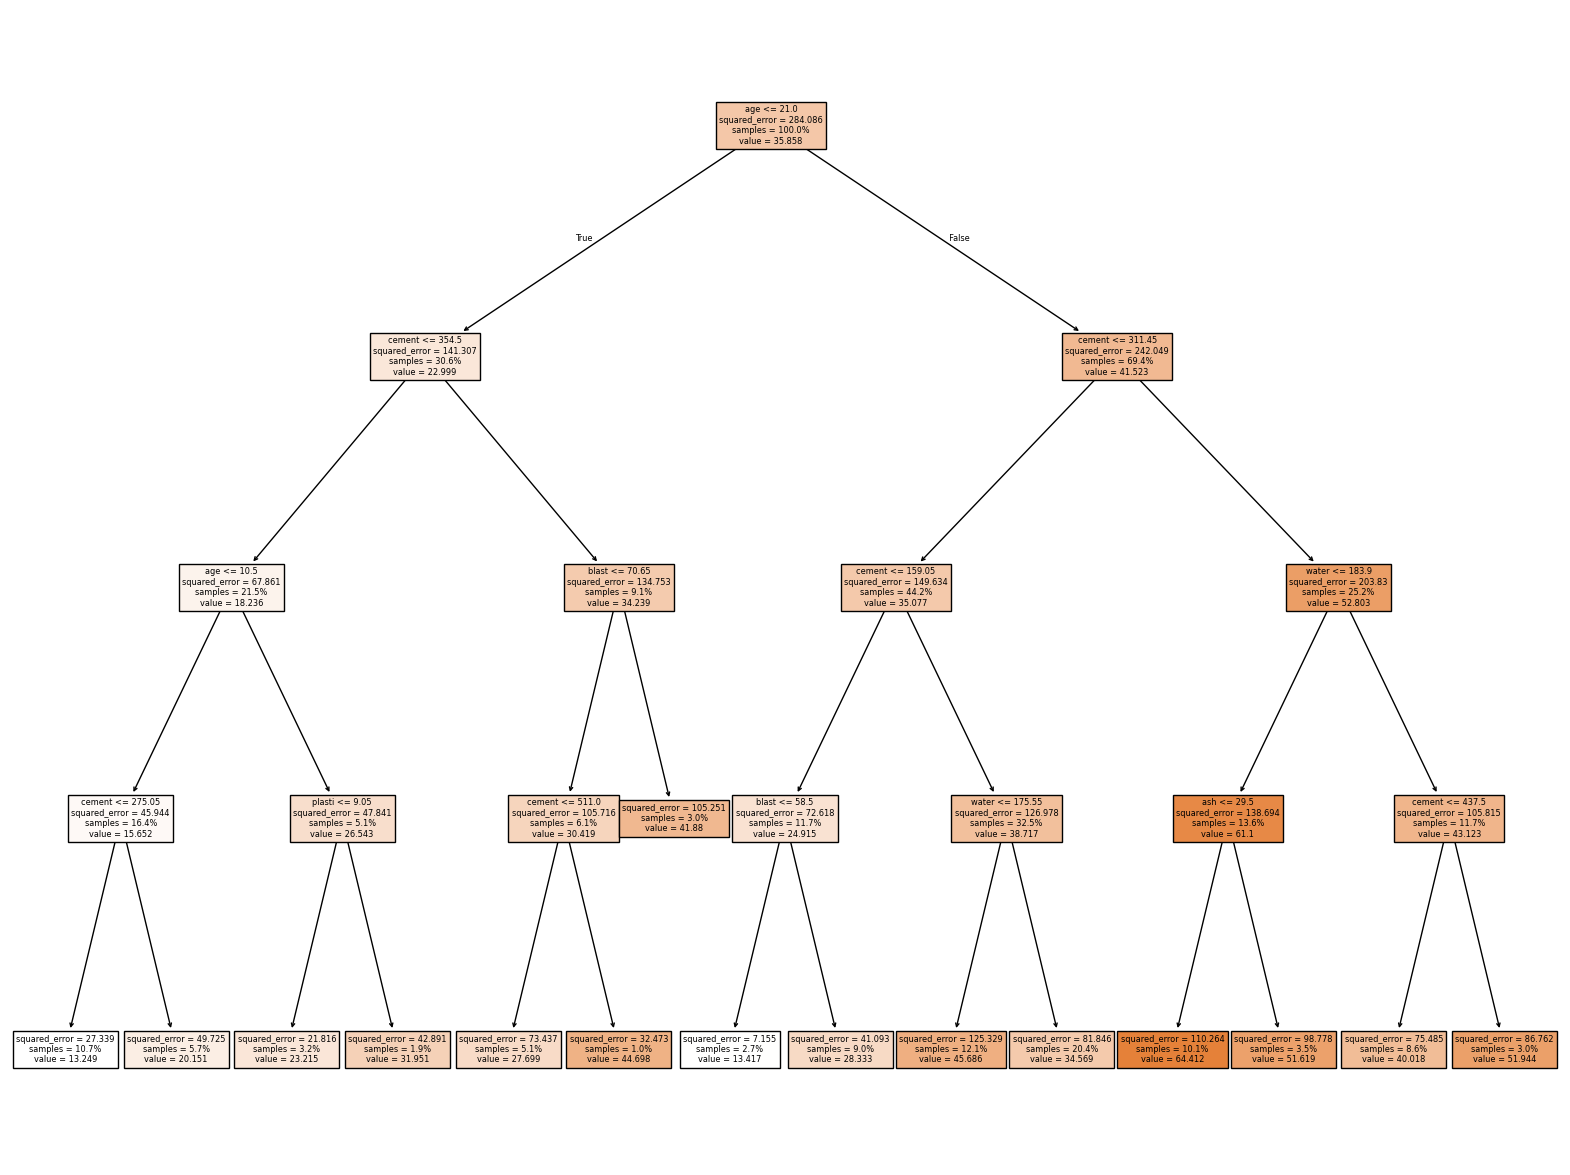

In [42]:
plt.figure(figsize=(20, 15))
plot_tree(arbol3, feature_names=X_c.columns.tolist(), filled=True,
proportion = True)
plt.show()

In [51]:
## tuneo y evaluación predictiva del modelo para variable dependiente categórica.
params = {
"max_depth": [2, 3, 5, 10, 20],
"min_samples_split": [5, 10, 20, 50, 100],
"criterion": ["gini", "entropy"]
}
scoring_metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
#recordar que arbol2 es el árbol cuyas VI son todas las variables.
# cv = crossvalidation
grid_search = GridSearchCV(estimator=arbol2,
param_grid=params,
cv=4, scoring = scoring_metrics, refit="accuracy")
grid_search.fit(X_train, y_train)
# cv (k-fold) 5 está bien, lo ideal es mínimo 10. Cuantos más folds, más sensible.

AttributeError: 'bool' object has no attribute 'all'

AttributeError: 'bool' object has no attribute 'all'

GridSearchCV(cv=4,
             estimator=DecisionTreeClassifier(max_depth=4,
                                              min_samples_split=30),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_split': [5, 10, 20, 50, 100]},
             refit='accuracy',
             scoring=['accuracy', 'precision_macro', 'recall_macro',
                      'f1_macro'])

In [52]:
# Obtener resultados del grid search
results = pd.DataFrame(grid_search.cv_results_)
# Mostrar resultados
print("Resultados de Grid Search:")
print(results[["params","mean_test_accuracy",
"mean_test_precision_macro",
"mean_test_recall_macro", "mean_test_f1_macro"]])
# Obtener el mejor modelo
best_model = grid_search.best_estimator_
print(grid_search.best_estimator_)
#Después de sacar ese best estimator no te quedas con él, tienes que explorar la robustez!!
#hay que representar simepre los hiperparámetros de la profundidad que escogimos con la mediad de bondad de ajuste de interés;
#; a veces, da igual :) Esto es sobre train

Resultados de Grid Search:
                                               params  mean_test_accuracy  \
0   {'criterion': 'gini', 'max_depth': 2, 'min_sam...            0.650421   
1   {'criterion': 'gini', 'max_depth': 2, 'min_sam...            0.650421   
2   {'criterion': 'gini', 'max_depth': 2, 'min_sam...            0.653109   
3   {'criterion': 'gini', 'max_depth': 2, 'min_sam...            0.653109   
4   {'criterion': 'gini', 'max_depth': 2, 'min_sam...            0.653109   
5   {'criterion': 'gini', 'max_depth': 3, 'min_sam...            0.625964   
6   {'criterion': 'gini', 'max_depth': 3, 'min_sam...            0.631399   
7   {'criterion': 'gini', 'max_depth': 3, 'min_sam...            0.628711   
8   {'criterion': 'gini', 'max_depth': 3, 'min_sam...            0.620588   
9   {'criterion': 'gini', 'max_depth': 3, 'min_sam...            0.636834   
10  {'criterion': 'gini', 'max_depth': 5, 'min_sam...            0.639493   
11  {'criterion': 'gini', 'max_depth': 5, 'min_sa

# Una vez que el top-5 o top-3 se prueban los modelos sobre test. Hay que valorar el sobreajuste. Análisis de errores.
### Sacas la función de densidad de los errores de los modelos, y sacas los puntos de corte (matrices de confusión...)
### Una posibilidad es aplicar clustering. El modelo funciona y acierta en x tipo de observación, y el error está en y cluster. 

In [54]:
# Para seleccionar una parametrización específica y la mejor de acuerdo con el criterio
# de GridSearch, acceder a esta y conocer su combinación.
results.iloc[8].params
# (En este caso, son ejemplos de selección aleatorios para ilustrar el script de selección y representación),.
# se selecciona el modelo candidato, y se procede a analizar su robustez a lo largo de cross validation.
res_1 = results[["split0_test_accuracy", "split1_test_accuracy","split2_test_accuracy", "split3_test_accuracy"]].iloc[2]
res_2 = results[["split0_test_accuracy", "split1_test_accuracy","split2_test_accuracy", "split3_test_accuracy"]].iloc[4]
res_3 = results[["split0_test_accuracy", "split1_test_accuracy","split2_test_accuracy", "split3_test_accuracy"]].iloc[18]

C:\Users\Sebitas\AppData\Local\Temp\ipykernel_20420\1368377278.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([res_1.values,res_2.values,res_3.values], labels = ["res_1","res_2","res_3"])


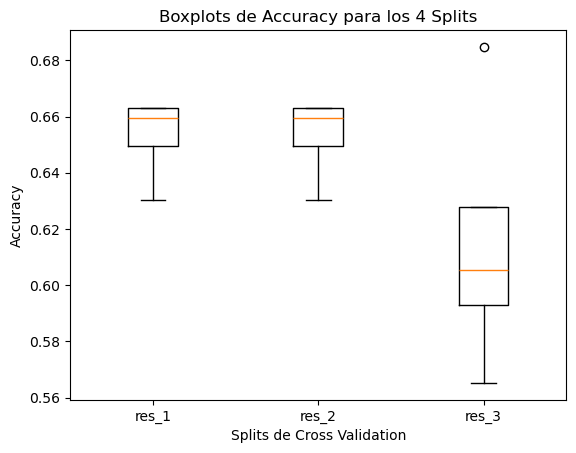

In [56]:
# Crear un boxplot para los cuatro valores de accuracy
plt.boxplot([res_1.values,res_2.values,res_3.values], labels = ["res_1","res_2","res_3"])
plt.title("Boxplots de Accuracy para los 4 Splits")
plt.xlabel("Splits de Cross Validation")
plt.ylabel("Accuracy")
plt.show()
# Nótese en la solución que boxplots con gran amplitud no son deseables,
# ya que se caracterizan por poca robustez de la solución

In [ ]:
# Obtener el mejor modelo (best estimador, o el seleccionado dado los pasos anteriores).
best_model = grid_search.best_estimator_
# Ajustar el mejor modelo con todo el conjunto de entrenamiento
best_model.fit(X_train, y_train)
# Predicciones en conjunto de entrenamiento y prueba
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

In [ ]:
#medidas de bondad de ajuste en train
conf_matrix = confusion_matrix(y_train, y_train_pred)
print("Matriz de Confusión:")
print(conf_matrix)
print("\nMedidas de Desempeño:")
print(classification_report(y_train, y_train_pred))


In [ ]:
y_train_auc = pd.get_dummies(y_train,drop_first=True)
# Calcular el área bajo la curva ROC (AUC)
y_prob_train = best_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train_auc, y_prob_train)
roc_auc = auc(fpr, tpr)
print(f"\nÁrea bajo la curva ROC (AUC): {roc_auc:.2f}")
# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# medidas de bondad de ajuste en test
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Matriz de Confusión:")
print(conf_matrix)
print("\nMedidas de Desempeño:")
print(classification_report(y_test, y_test_pred))


In [ ]:
y_test_auc = pd.get_dummies(y_test,drop_first=True)
# Calcular el área bajo la curva ROC (AUC)
y_prob_test = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_auc, y_prob_test)
roc_auc_test = auc(fpr, tpr)
print(f"\nÁrea bajo la curva ROC (AUC): {roc_auc:.2f}")
# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()


In [ ]:
plt.figure(figsize=(20, 15))
plot_tree(best_model, feature_names=X.columns.tolist(), filled=True,
proportion = True)
plt.show()


In [21]:
X.dtypes

sbp            int64
tobacco      float64
ldl          float64
adiposity    float64
famhist         bool
typea          int64
obesity      float64
alcohol      float64
age            int64
dtype: object

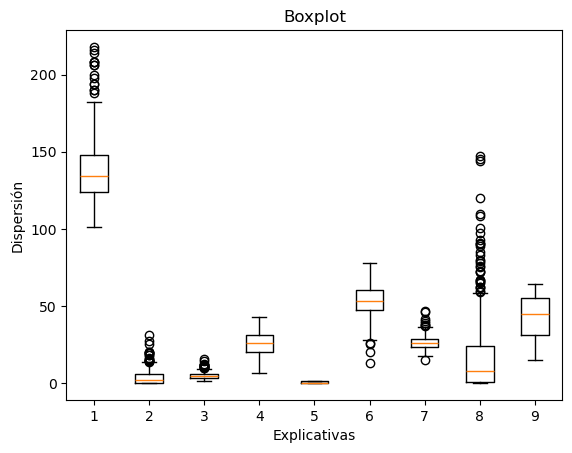

In [20]:
plt.boxplot((X))
plt.title("Boxplot")
plt.xlabel("Explicativas")
plt.ylabel("Dispersión")
plt.show()

In [22]:
# ES IMPORTANTE QUE LA DISTRIBUCIÓN DE LAS CLASES SEA "SIMILAR" EN TRAIN Y TEST.
print(f"La frecuencia de cada clase en train es: \n{y_train.value_counts(normalize=True)}")
print(f"\nLa frecuencia de cada clase en test es: \n{y_test.value_counts(normalize=True)}")

La frecuencia de cada clase en train es: 
chd
No     0.655827
Yes    0.344173
Name: proportion, dtype: float64

La frecuencia de cada clase en test es: 
chd
No     0.645161
Yes    0.354839
Name: proportion, dtype: float64


In [7]:
print(df.head())

   sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  age  chd
0  160    12.00  5.73      23.11        1     49    25.30    97.20   52  Yes
1  144     0.01  4.41      28.61        0     55    28.87     2.06   63  Yes
2  118     0.08  3.48      32.28        1     52    29.14     3.81   46   No
3  170     7.50  6.41      38.03        1     51    31.99    24.26   58  Yes
4  134    13.60  3.50      27.78        1     60    25.99    57.34   49  Yes


In [8]:
# Crear el árbol de decisión base. 
# OJO, estos no son los mejores parámetros; solo son ilustraciones para la comparación con bagging.
base_classifier = DecisionTreeClassifier(min_samples_split=10, criterion="gini", max_depth = 5, random_state = 123)
base_classifier.fit(X_train, y_train)
y_pred_base = base_classifier.predict(X_test)
# Evaluar el rendimiento del modelo
accuracy_a = accuracy_score(y_test, y_pred_base)
print(f"Precisión del árbol estándar: {accuracy_a}")

Precisión del árbol estándar: 0.6989247311827957


In [9]:
# n_estimators: Número de árboles en el bosque
# max_depth: Profundidad máxima de cada árbol
# min_samples_split: Número mínimo de muestras requeridas para dividir un nodo interno
# min_samples_leaf: Número mínimo de muestras requeridas para estar en un nodo hoja
# max_features: Número o proporción de características para ajustar cada árbol
# bootstrap: Si se deben realizar remuestreos con reemplazo (True) o sin reemplazo (False)
# n_jobs: Número de trabajadores para entrenar los árboles de forma paralela
# random_state: Semilla para reproducibilidad
RF_model = RandomForestClassifier(n_estimators = 60,bootstrap = True, max_depth = 20, min_samples_split=10, criterion="entropy",min_samples_leaf = 10,random_state=123)
RF_model.fit(X_train, y_train)
y_pred_rf = RF_model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Precisión del modelo con RF estándar: {accuracy_rf}")

Precisión del modelo con RF estándar: 0.7096774193548387


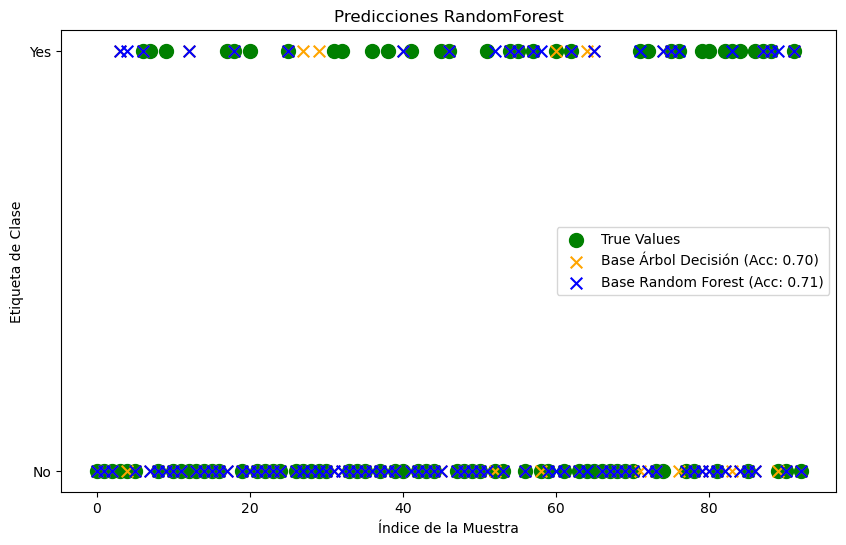

In [10]:
# Crear un gráfico de dispersión para comparar las predicciones
plt.figure(figsize=(10, 6))

plt.scatter(np.arange(len(y_test)), y_test, color="green", label="True Values", marker="o", s=100)
plt.scatter(np.arange(len(y_test)), y_pred_base, color="orange", label=f"Base Árbol Decisión (Acc: {accuracy_a:.2f})", marker="x", s=70)
plt.scatter(np.arange(len(y_test)), y_pred_rf, color="blue", label=f"Base Random Forest (Acc: {accuracy_rf:.2f})", marker="x", s=70)

plt.title("Predicciones RandomForest")
plt.xlabel("Índice de la Muestra")
plt.ylabel("Etiqueta de Clase")
plt.legend()
plt.show()

In [11]:
# se procede a observar el posible sobreajuste comparando predicciones en train y test.
# predicciones significativamente mayores en train que en test puede indicar sobreajuste.
# Predicciones en conjunto de entrenamiento y prueba
y_train_pred = RF_model.predict(X_train)
y_test_pred = RF_model.predict(X_test)
print(f"Se tiene un accuracy para train de: {accuracy_score(y_train,y_train_pred)}")
print(f"Se tiene un accuracy para test de: {accuracy_score(y_test,y_test_pred)}")
print("Nótese la diferencia en accuracy para ambos conjuntos de datos y el posible sobreajuste.")

Se tiene un accuracy para train de: 0.8346883468834688
Se tiene un accuracy para test de: 0.7096774193548387
Nótese la diferencia en accuracy para ambos conjuntos de datos y el posible sobreajuste.


In [53]:
RF_model.get_params

<bound method BaseEstimator.get_params of RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_leaf=10,
                       min_samples_split=10, n_estimators=60, random_state=123)>

In [12]:
# Se puede seleccionar un grill extenso y meditado sobre los distintos parámetros con los que jugar.
params = {
    "n_estimators" : [50,100,150,200,250],
    "max_depth": [2, 3, 5, 10, 20],
    "bootstrap": [True, False],
    "min_samples_leaf" : [3,10,30],
    "min_samples_split": [5, 10, 20, 50, 100],
    "criterion": ["gini", "entropy"]
}

scoring_metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
#recordar que arbol2 es el árbol cuyas VI son todas las variables.
# cv = crossvalidation
grid_search_RF = GridSearchCV(estimator=RF_model, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics, refit="accuracy")
grid_search_RF.fit(X_train, y_train)


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(criterion='entropy', max_depth=20,
                                              min_samples_leaf=10,
                                              min_samples_split=10,
                                              n_estimators=60,
                                              random_state=123),
             param_grid={'bootstrap': [True, False],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [3, 10, 30],
                         'min_samples_split': [5, 10, 20, 50, 100],
                         'n_estimators': [50, 100, 150, 200, 250]},
             refit='accuracy',
             scoring=['accuracy', 'precision_macro', 'recall_macro',
                      'f1_macro'])

In [13]:
print("En el caso anterior, se observa que el parámetro max_depth tiene un valor de 20, indicador que de mayores valores\n pueden suponer mejora, por lo que modificar el grill puede ser indicado en ese parámetro. \nIgualmente puede ocurrir con min_samples_split, el cual, parece indicar la búsqueda \nde valores menores y más continuados, por ejemplo: [8,9,10,11,12]")

En el caso anterior, se observa que el parámetro max_depth tiene un valor de 20, indicador que de mayores valores
 pueden suponer mejora, por lo que modificar el grill puede ser indicado en ese parámetro. 
Igualmente puede ocurrir con min_samples_split, el cual, parece indicar la búsqueda 
de valores menores y más continuados, por ejemplo: [8,9,10,11,12]


In [14]:
# Obtener el mejor modelo
best_model_RF = grid_search_RF.best_estimator_
print(grid_search_RF.best_estimator_)
y_pred_rf = best_model_RF.predict(X_test)
accuracy_rf_gs = accuracy_score(y_test, y_pred_rf)
# Evaluar el rendimiento del modelo
print(f"Precisión del árbol estándar: {accuracy_rf_gs}")

RandomForestClassifier(bootstrap=False, criterion='entropy', max_depth=10,
                       min_samples_leaf=10, min_samples_split=100,
                       n_estimators=250, random_state=123)
Precisión del árbol estándar: 0.6989247311827957


In [15]:
# se procede a observar el posible sobreajuste comparando predicciones en train y test.
# predicciones significativamente mayores en train que en test puede indicar sobreajuste.
# Predicciones en conjunto de entrenamiento y prueba
y_train_pred = best_model_RF.predict(X_train)
y_test_pred = best_model_RF.predict(X_test)
print(f"Se tiene un accuracy para train de: {accuracy_score(y_train,y_train_pred)}")
print(f"Se tiene un accuracy para test de: {accuracy_score(y_test,y_test_pred)}")
print("Comprobar que la diferencia no sea muy grande por temas de sobreajuste")

Se tiene un accuracy para train de: 0.7886178861788617
Se tiene un accuracy para test de: 0.6989247311827957
Comprobar que la diferencia no sea muy grande por temas de sobreajuste


In [16]:
# Obtener resultados del grid search
results = pd.DataFrame(grid_search_RF.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_bootstrap,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,...,mean_test_recall_macro,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
0,0.047379,0.005418,0.014250,0.002377,True,gini,2,3,5,50,...,0.583507,0.053125,1214,0.523688,0.469358,0.661711,0.611688,0.566611,0.074794,1218
1,0.104920,0.006516,0.011717,0.006765,True,gini,2,3,5,100,...,0.575342,0.042917,1263,0.523688,0.488889,0.641558,0.581818,0.558988,0.058093,1242
2,0.157067,0.006658,0.016570,0.000970,True,gini,2,3,5,150,...,0.577677,0.039296,1241,0.545626,0.469358,0.598927,0.623188,0.559275,0.059010,1241
3,0.211944,0.003825,0.017211,0.001671,True,gini,2,3,5,200,...,0.583633,0.041885,1210,0.553457,0.469358,0.620650,0.623188,0.566663,0.062754,1215
4,0.260736,0.003867,0.021430,0.009317,True,gini,2,3,5,250,...,0.583507,0.050774,1214,0.531143,0.469358,0.661711,0.602878,0.566272,0.072586,1220


In [72]:
print(results.columns)

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_bootstrap', 'param_criterion', 'param_max_depth',
       'param_min_samples_leaf', 'param_min_samples_split',
       'param_n_estimators', 'params', 'split0_test_accuracy',
       'split1_test_accuracy', 'split2_test_accuracy', 'split3_test_accuracy',
       'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy',
       'split0_test_precision_macro', 'split1_test_precision_macro',
       'split2_test_precision_macro', 'split3_test_precision_macro',
       'mean_test_precision_macro', 'std_test_precision_macro',
       'rank_test_precision_macro', 'split0_test_recall_macro',
       'split1_test_recall_macro', 'split2_test_recall_macro',
       'split3_test_recall_macro', 'mean_test_recall_macro',
       'std_test_recall_macro', 'rank_test_recall_macro',
       'split0_test_f1_macro', 'split1_test_f1_macro', 'split2_test_f1_macro',
       'split3_test_f1_macro', 'mean_test_f1_macro', 'std_

In [17]:
# Ordenar el DataFrame por la métrica de interés (por ejemplo, accuracy)
sorted_results = results.sort_values(by="mean_test_accuracy", ascending=True).head(5)
print(sorted_results)

      mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
1052       0.202205      0.006960         0.016118        0.003887   
421        0.101538      0.007811         0.011723        0.006768   
977        0.206296      0.003505         0.014989        0.004415   
1054       0.334559      0.007696         0.020954        0.006914   
981        0.128221      0.006265         0.012097        0.006993   

     param_bootstrap param_criterion param_max_depth param_min_samples_leaf  \
1052           False            gini              20                      3   
421             True         entropy               2                     10   
977            False            gini              10                      3   
1054           False            gini              20                      3   
981            False            gini              10                      3   

     param_min_samples_split param_n_estimators  ... mean_test_recall_macro  \
1052                     

In [18]:
# se selecciona el modelo candidato, y se procede a analizar su robustez a lo largo de cross validation.
res_1 = sorted_results[["split0_test_accuracy", "split1_test_accuracy","split2_test_accuracy", "split3_test_accuracy"]].iloc[0]
res_2 = sorted_results[["split0_test_accuracy", "split1_test_accuracy","split2_test_accuracy", "split3_test_accuracy"]].iloc[1]
res_3 = sorted_results[["split0_test_accuracy", "split1_test_accuracy","split2_test_accuracy", "split3_test_accuracy"]].iloc[2]
res_4 = sorted_results[["split0_test_accuracy", "split1_test_accuracy","split2_test_accuracy", "split3_test_accuracy"]].iloc[3]
res_5 = sorted_results[["split0_test_accuracy", "split1_test_accuracy","split2_test_accuracy", "split3_test_accuracy"]].iloc[4]

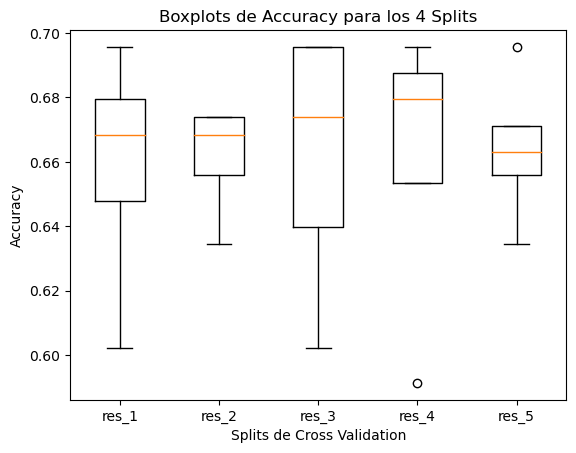

In [19]:
# Crear un boxplot para los cuatro valores de accuracy
plt.boxplot([res_1.values,res_2.values,res_3.values,res_4.values,res_5.values], labels = ["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de Accuracy para los 4 Splits")
plt.xlabel("Splits de Cross Validation")
plt.ylabel("Accuracy")
plt.show()
# Nótese en la solución que boxplots con gran amplitud no son deseables, ya que se caracterizan por poca robustez de la solución

In [20]:
# seleccionemos el segundo modelo dada su mayor robustez con respecto al propuesto por GridSearch
# nótese que "**" es para desempaquetar una lista de valores.
random_f_2 = RandomForestClassifier(**sorted_results["params"].iloc[1],random_state=123)
random_f_2.fit(X_train, y_train)
res_rf_2 = random_f_2.predict(X_test)

In [1]:
accuracy_score(y_test,res_rf_2)

NameError: name 'accuracy_score' is not defined

In [24]:
# Si se quiere conocer quién tiene mayor robustez en sensibilidad por cuestiones de criterio exógeno:
sorted_results[["std_test_recall_macro"]]

,std_test_recall_macro
1052,0.041808
421,0.015585
977,0.045500
1054,0.051148
981,0.030065


In [ ]:
print("Resultados para Modelo")
print(classification_report(y_test, res_rf_2))

A CONTINUACIÓN, SE REALIZARÁ EL EJEMPLO PARA EL CASO DE PROBLEMAS DE REGRESIÓN.

In [26]:
file_path = "C:/Users/user/OneDrive - Universidad Complutense de Madrid (UCM)/Escritorio/A_Doctorado/23/00_DOCENCIA/Máster Tit_Propio/Árboles/compress.csv"  # Reemplaza con la ruta correcta de tu archivo
file_path_3 = "E:/OneDrive - Universidad Complutense de Madrid (UCM)/Escritorio/A_Doctorado/23/00_DOCENCIA/Máster Tit_Propio/Árboles/compress.csv"  # Reemplaza con la ruta correcta de tu archivo

compress = pd.read_csv(file_path_3)
compress.head()

,cstrength,cement,blast,ash,water,plasti,aggreg,fineagg,age
0,79.99,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,61.89,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,40.27,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,41.05,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,44.30,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [28]:
# Separar las variables predictoras y la variable de respuesta.
X_c = compress.drop("cstrength", axis=1)
y_c = compress["cstrength"]

RF_R = RandomForestRegressor(n_estimators = 60,bootstrap = True, max_depth = 20, min_samples_split=10, criterion="absolute_error",min_samples_leaf = 10,random_state=123)
# Crear un conjunto de entrenamiento y uno de prueba
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=123)
# Construir el modelo de árbol de decisiones
RF_R.fit(X_train_c, y_train_c)

RandomForestRegressor(criterion='absolute_error', max_depth=20,
                      min_samples_leaf=10, min_samples_split=10,
                      n_estimators=60, random_state=123)

In [31]:
#se valora el posible sobreajuste
pred_rf_c_train = RF_R.predict(X_train_c)
pred_rf_c_test = RF_R.predict(X_test_c)
print(f"MAE del modelo en train:{mean_absolute_error(y_train_c,pred_rf_c_train)}")
print(f"MAE del modelo en test:{mean_absolute_error(y_test_c,pred_rf_c)}")

MAE del modelo en train:4.046392597087379
MAE del modelo en test:4.916126618122975


In [ ]:
# En caso de necesitar probar diferentes parametrizaciones. En este caso, iremos directamente a la validación cruzada.
params_c = {
    "max_depth": [2, 3, 5, 10, 20],
    "min_samples_split": [5, 10, 20, 50, 100],
    "criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"]
}
# Definir las métricas de evaluación que deseas utilizar



In [58]:
print(RF_R.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': 20, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 60, 'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0, 'warm_start': False}


In [60]:
scoring_metrics_c = {
    "MAE": make_scorer(mean_absolute_error),
    "MSE": make_scorer(mean_squared_error)
}
# los parámetros necesitan presentar formato lista.
params = {
    "bootstrap": [True], 
    "criterion": ["absolute_error"], 
    "max_depth": [20], 
    "max_features": [1.0], 
    "min_samples_leaf": [10], 
    "min_samples_split": [10],
    "n_estimators": [60],
    "random_state": [123]
}
grid_search_rf_c = GridSearchCV(estimator=RF_R, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics_c, refit="MAE")
grid_search_rf_c.fit(X_train_c, y_train_c)

GridSearchCV(cv=4,
             estimator=RandomForestRegressor(criterion='absolute_error',
                                             max_depth=20, min_samples_leaf=10,
                                             min_samples_split=10,
                                             n_estimators=60,
                                             random_state=123),
             param_grid={'bootstrap': [True], 'criterion': ['absolute_error'],
                         'max_depth': [20], 'max_features': [1.0],
                         'min_samples_leaf': [10], 'min_samples_split': [10],
                         'n_estimators': [60], 'random_state': [123]},
             refit='MAE',
             scoring={'MAE': make_scorer(mean_absolute_error),
                      'MSE': make_scorer(mean_squared_error)})

In [62]:
pd.DataFrame(grid_search_c.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_bootstrap,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,...,mean_test_MAE,std_test_MAE,rank_test_MAE,split0_test_MSE,split1_test_MSE,split2_test_MSE,split3_test_MSE,mean_test_MSE,std_test_MSE,rank_test_MSE
0,0.500562,0.008079,0.008319,0.008319,True,absolute_error,20,1.0,10,10,...,5.332337,0.270328,1,46.600223,46.403586,48.97246,55.02191,49.249545,3.482648,1


split0_test_MAE    5.202713
split1_test_MAE    5.168623
split2_test_MAE    5.158319
split3_test_MAE    5.799694
Name: 0, dtype: float64


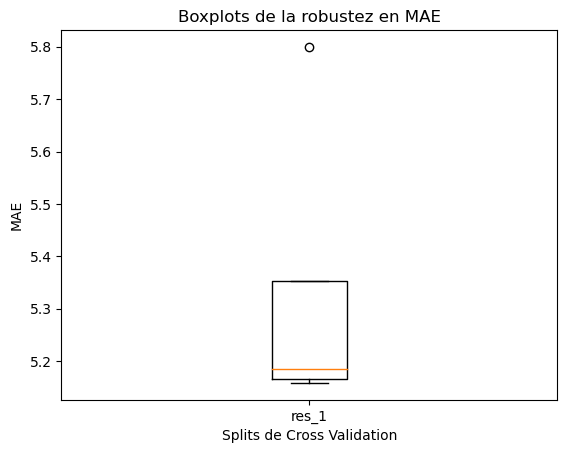

In [72]:
res_1 = pd.DataFrame(grid_search_c.cv_results_)[["split0_test_MAE", "split1_test_MAE","split2_test_MAE","split3_test_MAE"]].iloc[0]
print(res_1)
# Crear un boxplot para los cuatro valores de accuracy
plt.boxplot([res_1.values], labels = ["res_1"])
plt.title("Boxplots de la robustez en MAE")
plt.xlabel("Splits de Cross Validation")
plt.ylabel("MAE")
plt.show()

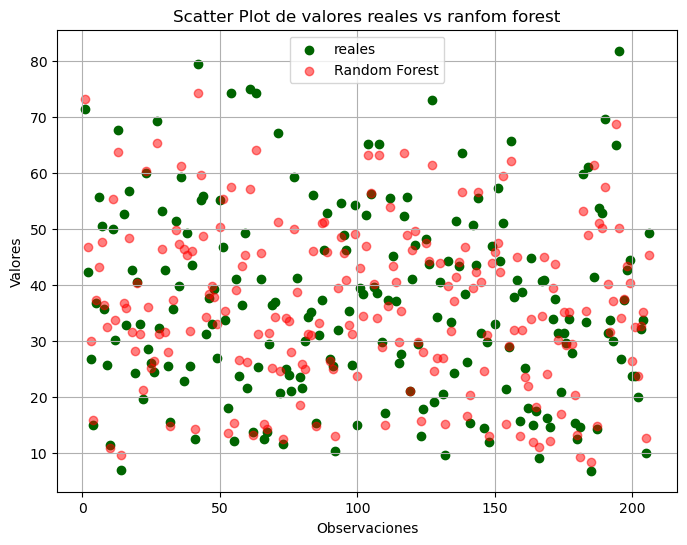

In [74]:
indices = np.arange(1, len(y_test_c) + 1)

plt.figure(figsize=(8, 6))
plt.scatter(indices, y_test_c, color="darkgreen", label="reales")  # Puedes ajustar el color según tus preferencias

plt.scatter(indices, pred_rf_c_test, color="red", alpha=0.5, label="Random Forest")  # Puedes ajustar el color y la transparencia según tus preferencias

plt.title("Scatter Plot de valores reales vs ranfom forest")
plt.xlabel("Observaciones")
plt.ylabel("Valores")
plt.legend()  # Agregar leyenda
plt.grid(True)
plt.show()

In [77]:
# Calcular diferentes medidas de bondad de ajuste
mae = mean_absolute_error(y_test_c, pred_rf_c_test)
mse = mean_squared_error(y_test_c, pred_rf_c_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_c, pred_rf_c_test)

# Imprimir las métricas
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"MSE (Error Cuadrático Medio): {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"R2: {r2}")

MAE (Error Absoluto Medio): 4.92
MSE (Error Cuadrático Medio): 43.83
RMSE (Raíz del Error Cuadrático Medio): 6.62
R2: 0.8402963970008323
